**IMPORT DATA**

In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(r'ReviewHotelUNY.csv')
df.head()

Saving Review Hotel UNY.csv to Review Hotel UNY (4).csv


,searchString,reviewerId,reviewerUrl,name,reviewerNumberOfReviews,isLocalGuide,reviewerPhotoUrl,text,textTranslated,publishAt,...,reviewsCount,url,price,cid,fid,hotelStars,imageUrl,scrapedAt,language,kgmid
0,Direct Detail URL: https://www.google.com/maps...,101874577009390163294,https://www.google.com/maps/contrib/1018745770...,ari sapta,88.0,True,https://lh3.googleusercontent.com/a-/ALV-UjX4-...,NaN,NaN,2 minggu lalu,...,1623,https://www.google.com/maps/search/?api=1&quer...,US$15,13675515934169918358,0x2e7a59b3fe486afd:0xbdc9314940646b96,Hotel bintang 2,https://lh3.googleusercontent.com/gps-cs-s/AHV...,2026-03-11T15:38:06.277Z,id,/g/1tj3hhf7
1,Direct Detail URL: https://www.google.com/maps...,101221172350850343174,https://www.google.com/maps/contrib/1012211723...,Resepsionis hotel,163.0,True,https://lh3.googleusercontent.com/a-/ALV-UjV28...,UNY Hotel,NaN,2 minggu lalu,...,1623,https://www.google.com/maps/search/?api=1&quer...,US$15,13675515934169918358,0x2e7a59b3fe486afd:0xbdc9314940646b96,Hotel bintang 2,https://lh3.googleusercontent.com/gps-cs-s/AHV...,2026-03-11T15:38:06.277Z,id,/g/1tj3hhf7
2,Direct Detail URL: https://www.google.com/maps...,100077016927840697687,https://www.google.com/maps/contrib/1000770169...,魏路貞Nuning Wilujeng,91.0,True,https://lh3.googleusercontent.com/a-/ALV-UjXEq...,Klo utk tinggal pas sad urusan dg UNY ya cocok...,NaN,2 minggu lalu,...,1623,https://www.google.com/maps/search/?api=1&quer...,US$15,13675515934169918358,0x2e7a59b3fe486afd:0xbdc9314940646b96,Hotel bintang 2,https://lh3.googleusercontent.com/gps-cs-s/AHV...,2026-03-11T15:38:06.277Z,id,/g/1tj3hhf7
3,Direct Detail URL: https://www.google.com/maps...,101992266779889730330,https://www.google.com/maps/contrib/1019922667...,armelia,2.0,False,https://lh3.googleusercontent.com/a/ACg8ocJo4g...,NaN,NaN,3 minggu lalu,...,1623,https://www.google.com/maps/search/?api=1&quer...,US$15,13675515934169918358,0x2e7a59b3fe486afd:0xbdc9314940646b96,Hotel bintang 2,https://lh3.googleusercontent.com/gps-cs-s/AHV...,2026-03-11T15:38:06.277Z,id,/g/1tj3hhf7
4,Direct Detail URL: https://www.google.com/maps...,104048641695440593978,https://www.google.com/maps/contrib/1040486416...,Fawaz Muhammad Sidiqi,76.0,True,https://lh3.googleusercontent.com/a-/ALV-UjWcV...,NaN,NaN,sebulan lalu,...,1623,https://www.google.com/maps/search/?api=1&quer...,US$15,13675515934169918358,0x2e7a59b3fe486afd:0xbdc9314940646b96,Hotel bintang 2,https://lh3.googleusercontent.com/gps-cs-s/AHV...,2026-03-11T15:38:06.277Z,id,/g/1tj3hhf7


**EDA**

**teks tebal**

In [ ]:
selected_columns = [
    "reviewId",
    "name",
    "text",
    "stars",
    "publishedAtDate",
    "isLocalGuide",
    "reviewerNumberOfReviews"
]

df_feature = df[selected_columns].copy()
df_feature.head()

,reviewId,name,text,stars,publishedAtDate,isLocalGuide,reviewerNumberOfReviews
0,Ci9DQUlRQUNvZENodHljRjlvT21kWU0wcHNUVlJyWTNBMF...,ari sapta,NaN,4.0,2026-02-25T11:49:52.578Z,True,88.0
1,Ci9DQUlRQUNvZENodHljRjlvT25vMlZsUkxTMU5IUlVGVG...,Resepsionis hotel,UNY Hotel,5.0,2026-02-21T16:39:09.773Z,True,163.0
2,Ci9DQUlRQUNvZENodHljRjlvT25CQlRqUmlWM2xhTVRrMV...,魏路貞Nuning Wilujeng,Klo utk tinggal pas sad urusan dg UNY ya cocok...,4.0,2026-02-20T23:38:49.561Z,True,91.0
3,Ci9DQUlRQUNvZENodHljRjlvT2pnNFpURTVWM1pmVlUxdm...,armelia,NaN,5.0,2026-02-12T16:18:40.882Z,False,2.0
4,Ci9DQUlRQUNvZENodHljRjlvT2xKVVRqZEpOMXBRTTJkam...,Fawaz Muhammad Sidiqi,NaN,5.0,2026-02-10T06:46:51.423Z,True,76.0


In [ ]:
#Cek missing value
df_feature.isnull().sum()

,0
reviewId,0
name,0
text,533
stars,5
publishedAtDate,0
isLocalGuide,0
reviewerNumberOfReviews,5


In [ ]:
#Mengatasi mising value
df_feature = df_feature.dropna()
df_feature.isnull().sum()

,0
reviewId,0
name,0
text,0
stars,0
publishedAtDate,0
isLocalGuide,0
reviewerNumberOfReviews,0


In [ ]:
df_feature.duplicated().sum()

np.int64(0)

In [ ]:
#Pembersih Teks
import re
def clean_text_lengkap(text):
    #Lowercase (membuat semua menjadi data kecil)
    text = str(text).lower()

    #Hapus nomor urut di awal (format 1; atau 2;)
    text = re.sub(r'^\d+;', '', text)

    #Hapus angka
    text = re.sub(r'\d+', '', text)

    #Hapus tanda baca dan simbol (termasuk ?? dan emote)
    text = re.sub(r'[^a-z\s]', '', text)

    #Merapikan spasi ganda
    text = " ".join(text.split())

    return text

df_feature['ulasan_bersih'] = df_feature['text'].apply(clean_text_lengkap)
df_feature[['text', 'ulasan_bersih']].head()

,text,ulasan_bersih
1,UNY Hotel,uny hotel
2,Klo utk tinggal pas sad urusan dg UNY ya cocok...,klo utk tinggal pas sad urusan dg uny ya cocok...
5,"2025 kesini karena ada acara untuk pekerjaan, ...",kesini karena ada acara untuk pekerjaan pada s...
6,I visit uny hotel dormitory for students of un...,i visit uny hotel dormitory for students of un...
7,Really worth the price for a budget standard r...,really worth the price for a budget standard r...


**TOKENISASI**

In [ ]:
df_feature['token'] = df_feature['ulasan_bersih'].apply(lambda x: x.split())
df_feature['token']

,token
1,"[uny, hotel]"
2,"[klo, utk, tinggal, pas, sad, urusan, dg, uny,..."
5,"[kesini, karena, ada, acara, untuk, pekerjaan,..."
6,"[i, visit, uny, hotel, dormitory, for, student..."
7,"[really, worth, the, price, for, a, budget, st..."
...,...
958,"[dekat, pusat, kota]"
959,"[harganya, relatif, murah]"
962,"[lokasi, ada, di, sekitar, kampus, uny, parkir..."
963,[nyaman]


**NORMALISASI**

In [ ]:
kamus_normalisasi = {
    'dg': 'dengan',
    'yg': 'yang',
    'gak': 'tidak',
    'gk': 'tidak',
    'bgt': 'banget',
    'makanan': 'makan',
    'enak2': 'enak-enak',
    'klo': 'kalau',
    'utk': 'untuk',
    'nggak': 'tidak',
    'td': 'tadi'
}
def normalisasi_teks(list_kata):
    return [kamus_normalisasi.get(kata, kata) for kata in list_kata]
df_feature['ulasan_normal'] = df_feature['token'].apply(normalisasi_teks)
df_feature[['token','ulasan_normal']].head()

,token,ulasan_normal
1,"[uny, hotel]","[uny, hotel]"
2,"[klo, utk, tinggal, pas, sad, urusan, dg, uny,...","[kalau, untuk, tinggal, pas, sad, urusan, deng..."
5,"[kesini, karena, ada, acara, untuk, pekerjaan,...","[kesini, karena, ada, acara, untuk, pekerjaan,..."
6,"[i, visit, uny, hotel, dormitory, for, student...","[i, visit, uny, hotel, dormitory, for, student..."
7,"[really, worth, the, price, for, a, budget, st...","[really, worth, the, price, for, a, budget, st..."


**STEMMING/LEMMA**

In [ ]:
#Stemming
!pip install Sastrawi

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()
df_feature['ulasan_final'] = df_feature['ulasan_normal'].apply(lambda x: [stemmer.stem(kata) for kata in x])

In [ ]:
df_feature['text_ready'] = df_feature['ulasan_final'].apply(lambda x: " ".join(x) if isinstance(x, list) else "")

df_clean = df_feature.dropna(subset=['text_ready']).copy()
df_clean = df_clean[df_clean['text_ready'].str.strip() != ""]

df_clean[['text_ready']].head()

,text_ready
1,uny hotel
2,kalau untuk tinggal pas sad urus dengan uny ya...
5,kesini karena ada acara untuk kerja pada saat ...
6,i visit uny hotel dormitory for students of un...
7,really worth the price for a budget standard r...


**TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Inisialisasi TF-IDF
tfidf = TfidfVectorizer(min_df=5, max_features=500)

#Fit dan Transform menggunakan data yang sudah bersih
X_tfidf = tfidf.fit_transform(df_clean['text_ready'])

#Buat DataFrame untuk melihat hasilnya
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

print(f"Dimensi Matriks TF-IDF: {X_tfidf.shape}")
tfidf_df.head()

Dimensi Matriks TF-IDF: (431, 214)


,ac,acara,ada,adalah,agak,air,aja,akan,aman,anak,...,ugm,umum,untuk,uny,utama,waktu,wifi,ya,yang,yogyakarta
0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.000000,0.776567,0.0,0.0,0.0,0.000000,0.0,0.000000
1,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.248011,0.246648,0.0,0.0,0.0,0.371433,0.0,0.000000
2,0.0,0.210886,0.444874,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.400622,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
3,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.000000,0.234254,0.0,0.0,0.0,0.000000,0.0,0.126522
4,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.16463,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000


**MENGHITUNG JUMLAH KATA**

In [ ]:
from collections import Counter
semua_kata = ' '.join(df_clean['text_ready']).split()
hitung_kata = Counter(semua_kata)

df_counts = pd.DataFrame(hitung_kata.most_common(), columns=['Kata', 'Jumlah'])
df_counts.head(10)

,Kata,Jumlah
0,hotel,146
1,dan,139
2,di,126
3,yang,106
4,kamar,105
5,nyaman,94
6,untuk,89
7,uny,77
8,bersih,71
9,tidak,67


**WORDCLOUD**

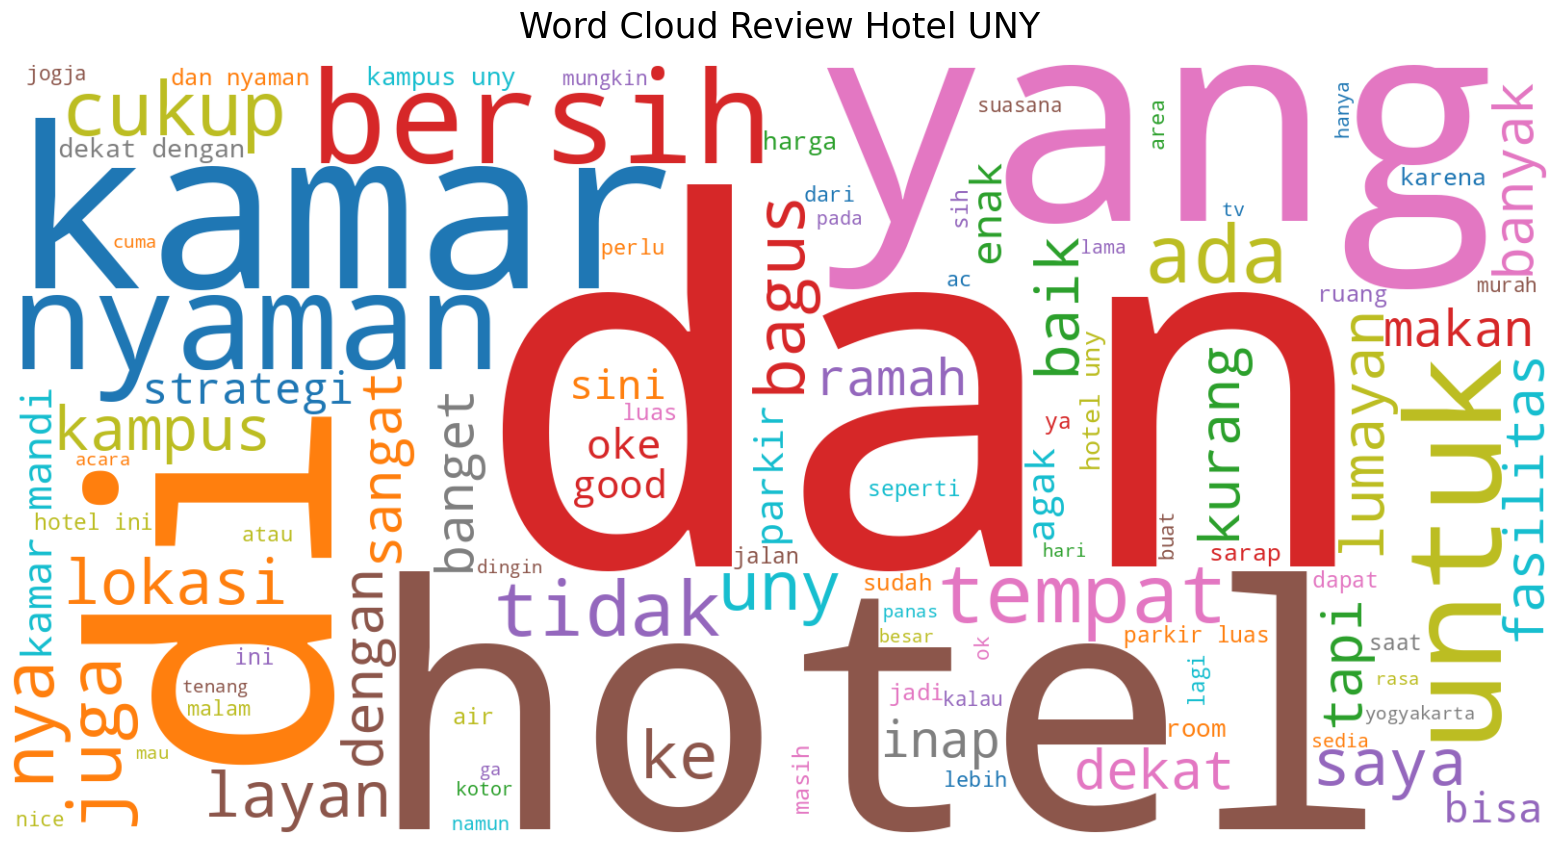

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

all_text = ' '.join(df_clean['text_ready'])

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    colormap='tab10',
    max_words=100,
    min_font_size=10
).generate(all_text)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Review Hotel UNY", fontsize=25, pad=20)
plt.show()

**EVALUASI**

In [ ]:
#Membuat fungsi untuk mengelompokkan bintang menjadi sentimen
def grouping_stars(stars):
    if stars >= 4:
        return 'Positif'
    elif stars <= 2:
        return 'Negatif'
    else:
        return 'Netral'

#menerapkan ke kolom baru bernama 'label'
df_clean['label'] = df_clean['stars'].apply(grouping_stars)

#Cek hasilnya
print(df_clean[['stars', 'label']].head())

   stars    label
1    5.0  Positif
2    4.0  Positif
5    4.0  Positif
6    5.0  Positif
7    5.0  Positif


Distribusi Label Sentimen:
label
Positif    354
Netral      49
Negatif     28
Name: count, dtype: int64


/tmp/ipykernel_6009/2689149653.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_clean, palette='viridis')


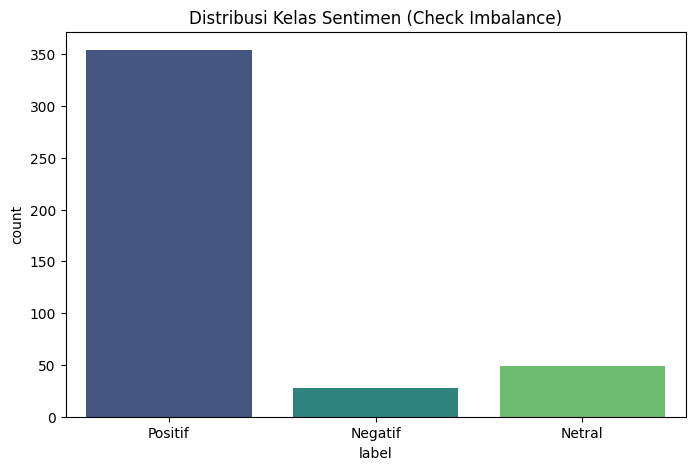

In [ ]:
# Cek Imbalance Data
print("Distribusi Label Sentimen:")
print(df_clean['label'].value_counts())

# Visualisasi Imbalance Data
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df_clean, palette='viridis')
plt.title('Distribusi Kelas Sentimen (Check Imbalance)')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=35)

print("Sebelum SMOTE")
print(Counter(y_train))

smote = SMOTE()

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Setelah SMOTE")
print(Counter(y_train_res))

Sebelum SMOTE
Counter({'Positif': 280, 'Netral': 41, 'Negatif': 23})
Setelah SMOTE
Counter({'Positif': 280, 'Negatif': 280, 'Netral': 280})


EVALUASI DATA TRAINING
Akurasi Training (RF): 89.29%

Laporan Klasifikasi Training:
               precision    recall  f1-score   support

     Negatif       1.00      0.93      0.96       280
      Netral       1.00      0.75      0.86       280
     Positif       0.76      1.00      0.86       280

    accuracy                           0.89       840
   macro avg       0.92      0.89      0.89       840
weighted avg       0.92      0.89      0.89       840

EVALUASI DATA TESTING
Akurasi Testing (RF): 82.76%

Laporan Klasifikasi Testing:
               precision    recall  f1-score   support

     Negatif       0.67      0.40      0.50         5
      Netral       0.20      0.12      0.15         8
     Positif       0.87      0.93      0.90        74

    accuracy                           0.83        87
   macro avg       0.58      0.49      0.52        87
weighted avg       0.80      0.83      0.81        87



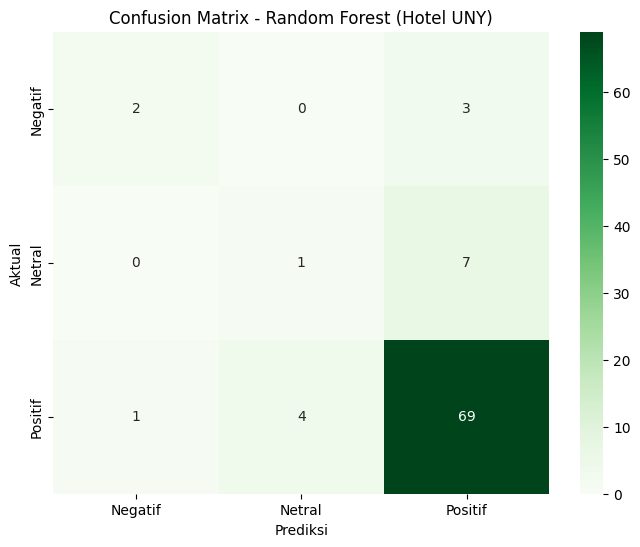

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Inisialisasi Model
model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=35)
model_rf.fit(X_train_res, y_train_res)
y_pred_train_rf = model_rf.predict(X_train_res)
y_pred_test_rf = model_rf.predict(X_test)

# OUTPUT EVALUASI TRAINING
print("EVALUASI DATA TRAINING")
print(f"Akurasi Training (RF): {accuracy_score(y_train_res, y_pred_train_rf) * 100:.2f}%")
print("\nLaporan Klasifikasi Training:\n", classification_report(y_train_res, y_pred_train_rf))

#OUTPUT EVALUASI TESTING
print("EVALUASI DATA TESTING")
print(f"Akurasi Testing (RF): {accuracy_score(y_test, y_pred_test_rf) * 100:.2f}%")
print("\nLaporan Klasifikasi Testing:\n", classification_report(y_test, y_pred_test_rf))

# 4. Visualisasi Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_test_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=model_rf.classes_,
            yticklabels=model_rf.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Random Forest (Hotel UNY)')
plt.show()